In [1]:
import pandas as pd
from pathlib import Path

data_path = Path.home() / "OneDrive" / "Pulpit" / "01_data_raw"

monthly_path = data_path / "MonthlyStockFile.xlsx"

df_m = pd.read_excel(monthly_path)

df_m.head()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\suus9\\OneDrive\\Pulpit\\01_data_raw\\MonthlyStockFile.xlsx'

In [ ]:
import pandas as pd
from pathlib import Path

data_path = Path.home() / "OneDrive" / "Pulpit" / "01_data_raw"
monthly_path = data_path / "MonthlyStockFile.xlsx"

df_raw = pd.read_excel(monthly_path, header=None)

df_raw.head()

,0
0,"PERMNO,HdrCUSIP,PrimaryExch,ShareClass,ShareTy..."
1,"10000,68391610,Q,A,NS,OMFGA,7952,3990,1986-01-..."
2,"10000,68391610,Q,A,NS,OMFGA,7952,3990,1986-02-..."
3,"10000,68391610,Q,A,NS,OMFGA,7952,3990,1986-03-..."
4,"10000,68391610,Q,A,NS,OMFGA,7952,3990,1986-04-..."


In [ ]:
df_m = df_raw[0].astype(str).str.split(",", expand=True)

# first row contains column names
df_m.columns = df_m.iloc[0]

# remove first row
df_m = df_m.iloc[1:].reset_index(drop=True)

df_m.head()

,PERMNO,HdrCUSIP,PrimaryExch,ShareClass,ShareType,Ticker,PERMCO,SICCD,MthCalDt,MthPrc,MthRet,ShrOut
0,10000,68391610,Q,A,NS,OMFGA,7952,3990,1986-01-31,4.375000,0.707317,3680
1,10000,68391610,Q,A,NS,OMFGA,7952,3990,1986-02-28,3.250000,-0.257143,3680
2,10000,68391610,Q,A,NS,OMFGA,7952,3990,1986-03-31,4.437500,0.365385,3680
3,10000,68391610,Q,A,NS,OMFGA,7952,3990,1986-04-30,4.000000,-0.098592,3793
4,10000,68391610,Q,A,NS,OMFGA,7952,3990,1986-05-30,3.109375,-0.222656,3793


In [ ]:
df_m.columns
df_m.shape

(1048575, 12)

In [ ]:
df_m = df_m.rename(columns={
    "PERMNO": "permno",
    "HdrCUSIP": "cusip",
    "PrimaryExch": "exchange",
    "ShareClass": "share_class",
    "ShareType": "share_type",
    "Ticker": "ticker",
    "PERMCO": "permco",
    "SICCD": "siccd",
    "MthCalDt": "date",
    "MthPrc": "price",
    "MthRet": "ret",
    "ShrOut": "shrout"
})

df_m["date"] = pd.to_datetime(df_m["date"], errors="coerce")
df_m["permno"] = pd.to_numeric(df_m["permno"], errors="coerce")
df_m["ret"] = pd.to_numeric(df_m["ret"], errors="coerce")
df_m["price"] = pd.to_numeric(df_m["price"], errors="coerce")
df_m["shrout"] = pd.to_numeric(df_m["shrout"], errors="coerce")

df_m["me"] = df_m["price"].abs() * df_m["shrout"]

df_m = df_m.sort_values(["permno", "date"])
df_m.head()

,permno,cusip,exchange,share_class,share_type,ticker,permco,siccd,date,price,ret,shrout,me
0,10000,68391610,Q,A,NS,OMFGA,7952,3990,1986-01-31,4.375000,0.707317,3680,16100.000000
1,10000,68391610,Q,A,NS,OMFGA,7952,3990,1986-02-28,3.250000,-0.257143,3680,11960.000000
2,10000,68391610,Q,A,NS,OMFGA,7952,3990,1986-03-31,4.437500,0.365385,3680,16330.000000
3,10000,68391610,Q,A,NS,OMFGA,7952,3990,1986-04-30,4.000000,-0.098592,3793,15172.000000
4,10000,68391610,Q,A,NS,OMFGA,7952,3990,1986-05-30,3.109375,-0.222656,3793,11793.859375


In [ ]:
df_m = df_m[(df_m["date"] >= "1995-01-01") & (df_m["date"] <= "2025-12-31")]

df_m.shape

(534896, 13)

In [ ]:
#data clean
df_m = df_m.dropna(subset=["permno", "date"])
df_m = df_m.drop_duplicates(subset=["permno", "date"])
df_m = df_m.dropna(subset=["ret"])
df_m = df_m[(df_m["ret"] > -1) & (df_m["ret"] < 10)]
df_m = df_m.dropna(subset=["price", "shrout"])
df_m = df_m[df_m["price"] != 0]
df_m = df_m[df_m["shrout"] > 0]
df_m["me"] = df_m["price"].abs() * df_m["shrout"]
df_m = df_m[df_m["price"].abs() > 5]
df_m = df_m[df_m["me"] > 1e6]   # remove microcaps
df_m = df_m[(df_m["date"] >= "1995-01-01") & (df_m["date"] <= "2025-12-31")]
df_m = df_m.sort_values(["permno", "date"])

In [ ]:
df_m["date"].min(), df_m["date"].max()

(Timestamp('1995-01-31 00:00:00'), Timestamp('2024-12-31 00:00:00'))

<Axes: xlabel='date'>

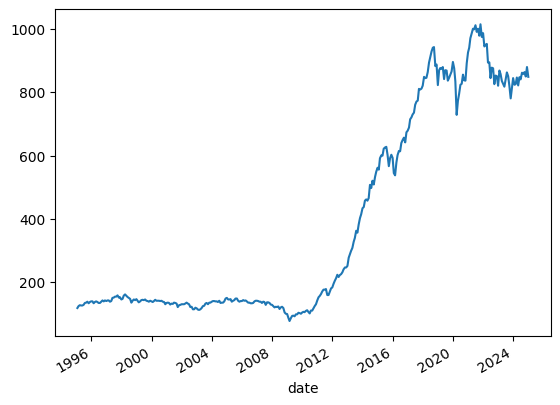

In [ ]:
df_m.groupby("date")["permno"].nunique().plot()

In [ ]:
df_m["ret"].describe()

count    137781.000000
mean          0.017322
std           0.130177
min          -0.983876
25%          -0.039455
50%           0.009218
75%           0.063720
max           9.889749
Name: ret, dtype: float64

In [ ]:
df_m["me"].describe()

count    1.377810e+05
mean     1.689613e+07
std      8.641632e+07
min      1.000001e+06
25%      1.692656e+06
50%      3.208335e+06
75%      7.963037e+06
max      3.766500e+09
Name: me, dtype: float64

In [ ]:
df_m.to_csv("crsp_monthly_clean.csv", index=False)

In [ ]:
df_m["ret_lag1"] = df_m.groupby("permno")["ret"].shift(1)
df_m["ret_lag3"] = df_m.groupby("permno")["ret"].rolling(3).mean().reset_index(0, drop=True)
df_m["ret_lag6"] = df_m.groupby("permno")["ret"].rolling(6).mean().reset_index(0, drop=True)
df_m["me_lag1"] = df_m.groupby("permno")["me"].shift(1)
df_m["price_lag1"] = df_m.groupby("permno")["price"].shift(1)
df_m = df_m.dropna(subset=["ret_lag1", "me_lag1"])
df_m["target_vol"] = None
df_m = df_m.sort_values(["permno", "date"])
df_m[[
    "permno", "date", "ret", "ret_lag1", "me", "me_lag1"
]].head(10)

,permno,date,ret,ret_lag1,me,me_lag1
5001,10026,2012-05-31,-0.017660,0.068624,1.038675e+06,1.057348e+06
5002,10026,2012-06-29,0.075673,-0.017660,1.117108e+06,1.038675e+06
5003,10026,2012-07-31,-0.022166,0.075673,1.093213e+06,1.117108e+06
5004,10026,2012-08-31,-0.011940,-0.022166,1.080161e+06,1.093213e+06
5005,10026,2012-09-28,0.006313,-0.011940,1.076657e+06,1.080161e+06
5006,10026,2012-10-31,-0.001047,0.006313,1.075531e+06,1.076657e+06
5007,10026,2012-11-30,0.098306,-0.001047,1.179312e+06,1.075531e+06
5008,10026,2012-12-31,0.018209,0.098306,1.199916e+06,1.179312e+06
5009,10026,2013-01-31,0.066792,0.018209,1.281084e+06,1.199916e+06
5010,10026,2013-02-28,0.015701,0.066792,1.301198e+06,1.281084e+06


In [ ]:
df_m["ret_lag3"] = (
    df_m.groupby("permno")["ret"]
    .shift(1)
    .rolling(3)
    .mean()
)

df_m["ret_lag6"] = (
    df_m.groupby("permno")["ret"]
    .shift(1)
    .rolling(6)
    .mean()
)

df_m["abs_ret_lag1"] = df_m.groupby("permno")["ret"].shift(1).abs()

In [ ]:
stock = df_m[df_m["permno"] == 10026]

stock[[
    "date",
    "ret",
    "ret_lag1",
    "ret_lag3",
    "ret_lag6"
]].head(15)

,date,ret,ret_lag1,ret_lag3,ret_lag6
5001,2012-05-31,-0.017660,0.068624,NaN,NaN
5002,2012-06-29,0.075673,-0.017660,NaN,NaN
5003,2012-07-31,-0.022166,0.075673,NaN,NaN
5004,2012-08-31,-0.011940,-0.022166,0.011949,NaN
5005,2012-09-28,0.006313,-0.011940,0.013856,NaN
5006,2012-10-31,-0.001047,0.006313,-0.009264,NaN
5007,2012-11-30,0.098306,-0.001047,-0.002225,0.004862
5008,2012-12-31,0.018209,0.098306,0.034524,0.024190
5009,2013-01-31,0.066792,0.018209,0.038489,0.014613
5010,2013-02-28,0.015701,0.066792,0.061102,0.029439


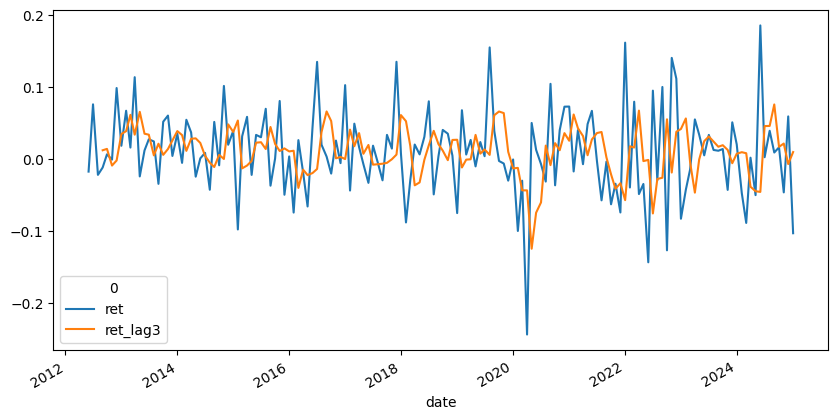

In [ ]:
import matplotlib.pyplot as plt

stock.set_index("date")[["ret", "ret_lag3"]].plot(figsize=(10,5))
plt.show()

In [ ]:
df_m["momentum_12m"] = (
    df_m.groupby("permno")["ret"]
    .shift(1)
    .rolling(12)
    .sum()
)

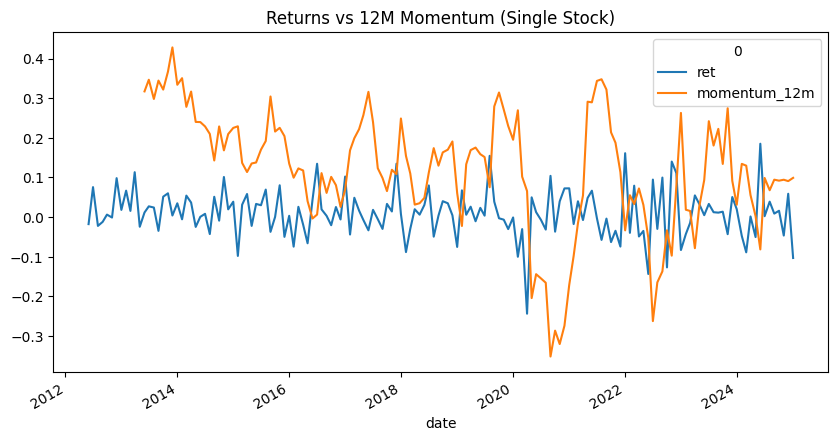

In [ ]:
import matplotlib.pyplot as plt

stock = df_m[df_m["permno"] == 10026].copy()

stock = stock.set_index("date")

stock[["ret", "momentum_12m"]].plot(figsize=(10,5))
plt.title("Returns vs 12M Momentum (Single Stock)")
plt.show()

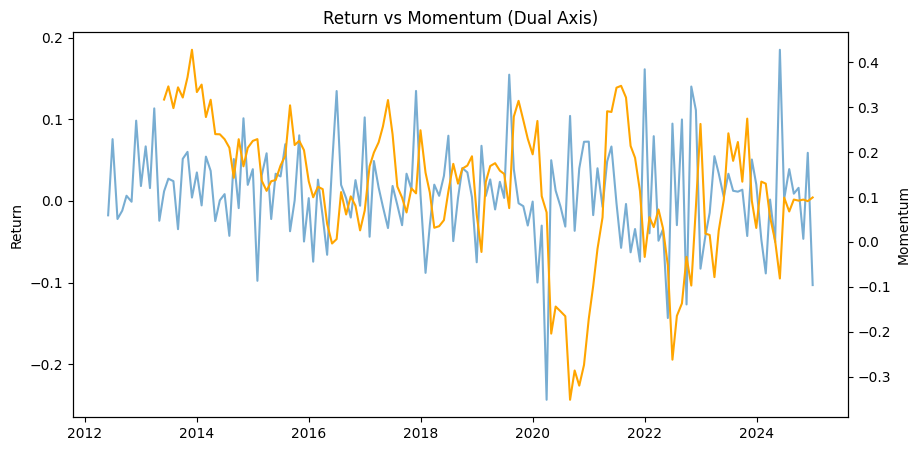

In [ ]:
fig, ax1 = plt.subplots(figsize=(10,5))

ax1.plot(stock.index, stock["ret"], label="Monthly Return", alpha=0.6)
ax1.set_ylabel("Return")

ax2 = ax1.twinx()
ax2.plot(stock.index, stock["momentum_12m"], color="orange", label="Momentum (12M)")
ax2.set_ylabel("Momentum")

plt.title("Return vs Momentum (Dual Axis)")
plt.show()

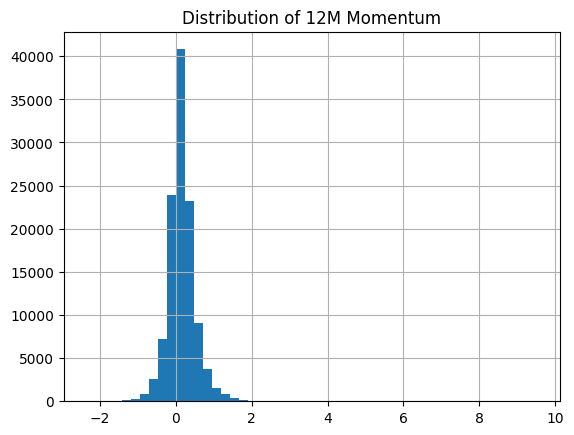

In [ ]:
df_m["momentum_12m"].hist(bins=50)
plt.title("Distribution of 12M Momentum")
plt.show()

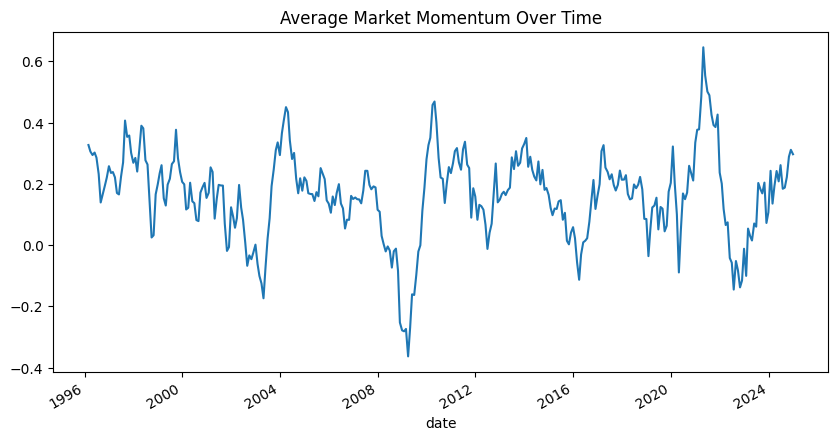

In [ ]:
momentum_time = df_m.groupby("date")["momentum_12m"].mean()

momentum_time.plot(figsize=(10,5))
plt.title("Average Market Momentum Over Time")
plt.show()